# Grid cells in the medial entorhinal cortex

This notebook demonstrates grid cells from real recordings in the DANDI Archive.
A grid cell fires whenever the animal occupies any vertex of a triangular
lattice that tiles the whole environment, so its firing-rate map contains many
discrete fields arranged in a hexagonal pattern. The signature is easiest to
read in the spatial autocorrelogram of the rate map, which shows a central peak
surrounded by six peaks at 60 degree intervals.

**Dataset.** [DANDI:000582](https://dandiarchive.org/dandiset/000582),
*Conjunctive Representation of Position, Direction, and Velocity in Entorhinal
Cortex* (Sargolini et al., Science 2006; Moser group, NTNU). Tetrode recordings
from the dorsocaudal medial entorhinal cortex (MEC) of Long-Evans rats foraging
for scattered food in an open box, with the position of head-mounted LEDs
tracked at 50 Hz. The dandiset holds 118 sessions from 15 rats and 620 sorted
units, with the recording layer given per unit.

**What the notebook does.**

1. Queries the DANDI API, streams the NWB files with `remfile` (no bulk download)
   and loads spikes and tracking into Pynapple objects.
2. Builds occupancy-normalised rate maps and spatial autocorrelograms.
3. Scores each unit with the standard expanding-annulus gridness score and
   calibrates it against a spike-train shuffling null.
4. Reports the population result: how many MEC units are grid cells, their grid
   spacing and orientation, their within-session stability, their conjunctive
   coding of head direction, and the shared orientation of grid cells recorded
   together.

The script is self-contained: every function it uses is defined here. Running it
from scratch takes roughly half an hour (mostly the 93,600 shuffles); if the
result files it writes are already present they are reused.

In [1]:
%matplotlib inline
import json
import os
import time

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import remfile
import requests
from pynwb import NWBHDF5IO
from scipy import ndimage, stats
from scipy.signal import fftconvolve
from tqdm.auto import tqdm

mpl.rcParams.update({"font.size": 9, "axes.titlesize": 9, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})

DANDISET = "000582"
API = f"https://api.dandiarchive.org/api/dandisets/{DANDISET}/versions/draft"
CACHE_DIR = os.environ.get("GRID_CACHE", "/tmp/remfile_cache_grid")

# Analysis parameters. Coordinates are in cm despite the NWB unit string saying
# "meters": the enclosure spans ~96 cm in most sessions.
BIN_SIZE = 2.5            # cm per spatial bin
SMOOTH_SIGMA_BINS = 2.0   # Gaussian sd used to smooth the maps (= 5 cm)
MIN_OCCUPANCY = 0.15      # s; smoothed occupancy needed for a bin to be defined
SPEED_THRESH = 2.5        # cm/s; slower samples are excluded
MIN_OVERLAP_BINS = 20     # minimum overlapping bins for an autocorrelation lag
MIN_SPIKES = 100          # units with fewer spikes are not analysed
N_SHUFFLE = 200
MIN_SHIFT = 20.0          # s, minimum circular shift in the shuffling control
SEED = 20260731

## 1. Finding the sessions

The DANDI API lists every asset in the dandiset. Each asset is one 10 or 20
minute open-field session with its sorted units and tracking.

In [2]:
def list_assets():
    r = requests.get(f"{API}/assets/", params={"page_size": 200}).json()
    assets = r["results"]
    while r.get("next"):
        r = requests.get(r["next"]).json()
        assets += r["results"]
    return sorted(assets, key=lambda a: a["path"])


def asset_url(asset_id):
    return f"{API}/assets/{asset_id}/download/"


assets = list_assets()
print(f"{len(assets)} assets, "
      f"{len(set(a['path'].split('/')[0] for a in assets))} subjects, "
      f"{sum(a['size'] for a in assets) / 1e9:.1f} GB total")
print(pd.Series([a["size"] / 1e6 for a in assets]).describe().round(1).to_string())

118 assets, 15 subjects, 1.9 GB total
count    118.0
mean      15.8
std        2.5
min        3.7
25%       15.6
50%       16.0
75%       16.8
max       19.1


## 2. Streaming one session

`remfile` reads the NWB file directly from the DANDI S3 bucket with an on-disk
cache, so only the chunks actually touched are transferred. The wideband
electrical series in these files is never read; the analysis needs only the
sorted spike times and the tracking.

In [3]:
def open_nwb(asset_id):
    f = remfile.File(asset_url(asset_id), disk_cache=remfile.DiskCache(CACHE_DIR))
    io = NWBHDF5IO(file=h5py.File(f, "r"), load_namespaces=True)
    return io.read()


example_asset = [a for a in assets if "sub-11138_ses-20040502" in a["path"]][0]
t0 = time.time()
nwb = open_nwb(example_asset["asset_id"])
print(f"opened in {time.time() - t0:.1f} s\n")
print(nwb.session_description[:300])
print("\nsubject:", nwb.subject.subject_id, nwb.subject.species, nwb.subject.sex)
print("processing modules:", {k: list(v.data_interfaces) for k, v in nwb.processing.items()})
print("units:", len(nwb.units), "columns:", nwb.units.colnames)
print(nwb.units.to_dataframe()[["unit_name", "histology", "depth"]].head())

opened in 0.2 s

This session includes spike and position times for recorded cells from a Long Evans rat that was running in a 1 x 1 meter enclosure. The cells were recorded in the dorsocaudal 25% portion of the medial entorhinal cortex (MEC).Position is given for two LEDs to enable calculation of head direction.

subject: 11138 Rattus norvegicus M
processing modules: {'behavior': ['Position'], 'ecephys': ['LFP']}
units: 7 columns: ('unit_name', 'spike_times', 'histology', 'hemisphere', 'depth')
   unit_name histology    depth
id                             
0       t3c2  MEC LIII  0.00255
1       t5c1  MEC LIII  0.00215
2       t5c2  MEC LIII  0.00215
3       t6c1  MEC LIII  0.00215
4       t6c2  MEC LIII  0.00215


## 3. Loading a session into Pynapple

Spikes become a `TsGroup`, tracking becomes a `TsdFrame`. Two details matter for
rate maps. Tracking dropouts shorter than a second are interpolated, and periods
when the rat is slower than 2.5 cm/s are dropped from the time support, because
stationary periods at the food-delivery corners otherwise dominate the occupancy
map. Head direction is available in the sessions that tracked two LEDs, as the
angle of the vector between them.

In [4]:
def _interp_gaps(t, xy, max_gap=1.0):
    out = xy.copy()
    for j in range(xy.shape[1]):
        v = out[:, j]
        bad = ~np.isfinite(v)
        if not bad.any():
            continue
        idx = np.flatnonzero(bad)
        gi = np.flatnonzero(~bad)
        for grp in np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1):
            if len(grp) and (t[grp[-1]] - t[grp[0]]) <= max_gap and gi.size:
                v[grp] = np.interp(t[grp], t[gi], v[gi])
    return out


def _bool_to_epochs(t, keep, dt):
    k = keep.astype(int)
    edges = np.diff(np.concatenate([[0], k, [0]]))
    return nap.IntervalSet(start=t[np.flatnonzero(edges == 1)],
                           end=t[np.flatnonzero(edges == -1) - 1] + dt)


def load_session(asset_id):
    nwb = open_nwb(asset_id)
    pos_mod = nwb.processing["behavior"]["Position"]
    led1 = pos_mod.spatial_series["SpatialSeriesLED1"]
    t = np.asarray(led1.timestamps[:], dtype=float)
    xy1 = np.asarray(led1.data[:], dtype=float)
    xy2 = None
    if "SpatialSeriesLED2" in pos_mod.spatial_series:
        xy2 = np.asarray(pos_mod.spatial_series["SpatialSeriesLED2"].data[:], dtype=float)
        good_hd = np.isfinite(xy1).all(axis=1) & np.isfinite(xy2).all(axis=1)

    xy1 = _interp_gaps(t, xy1)
    if xy2 is not None:
        xy2 = _interp_gaps(t, xy2)
    xy = xy1 if xy2 is None else 0.5 * (xy1 + xy2)

    dt = float(np.median(np.diff(t)))
    speed = np.hypot(*np.gradient(xy, dt, axis=0).T)
    speed = ndimage.uniform_filter1d(speed, size=int(round(0.4 / dt)))
    keep = np.isfinite(xy).all(axis=1) & (speed >= SPEED_THRESH)
    run_ep = _bool_to_epochs(t, keep, dt)

    hd = None
    if xy2 is not None:
        ang = np.arctan2(xy1[:, 1] - xy2[:, 1], xy1[:, 0] - xy2[:, 0])
        hd = nap.Tsd(t=t, d=np.mod(ang, 2 * np.pi))
        hd = hd.restrict(_bool_to_epochs(t, keep & good_hd, dt))

    position = nap.TsdFrame(t=t, d=xy, columns=["x", "y"])
    u = nwb.units
    tsgroup = nap.TsGroup(
        {i: nap.Ts(t=np.asarray(u["spike_times"][i], dtype=float)) for i in range(len(u))},
        time_support=run_ep,
        metadata=dict(
            unit_name=np.array([str(x) for x in u["unit_name"].data[:]]),
            histology=np.array([str(x) for x in u["histology"].data[:]]),
            depth=np.asarray(u["depth"].data[:], dtype=float),
        ),
    )
    return dict(units=tsgroup, position=position.restrict(run_ep), position_all=position,
                hd=hd, speed=nap.Tsd(t=t, d=speed), run_ep=run_ep,
                subject=str(nwb.subject.subject_id), dt=dt)


sess = load_session(example_asset["asset_id"])
print(sess["units"])
print(f"\nrunning epochs: {float(sess['run_ep'].tot_length()):.0f} s of "
      f"{float(sess['position_all'].t[-1]):.0f} s "
      f"({len(sess['run_ep'])} intervals)")

  Index     rate  unit_name    histology      depth
-------  -------  -----------  -----------  -------
      0  4.40213  t3c2         MEC LIII           0
      1  1.83877  t5c1         MEC LIII           0
      2  1.23434  t5c2         MEC LIII           0
      3  2.35763  t6c1         MEC LIII           0
      4  0.77556  t6c2         MEC LIII           0
      5  1.00131  t6c3         MEC LIII           0
      6  3.17142  t6c4         MEC LIII           0

running epochs: 549 s of 600 s (54 intervals)


## 4. The map extent differs between sessions

Most sessions were recorded in the 1 x 1 m box described in the dandiset
metadata, but 22 of the 118 sessions have tracking coordinates spanning about
190 cm. Because the physical calibration of that second group cannot be
confirmed from the file metadata, and because grid spacing in centimetres is
only meaningful if the calibration is known, the population analysis below uses
only the 96 sessions whose tracked extent is close to 1 m.

96 sessions near 1 m (median 97 cm), 22 larger (median 189 cm)


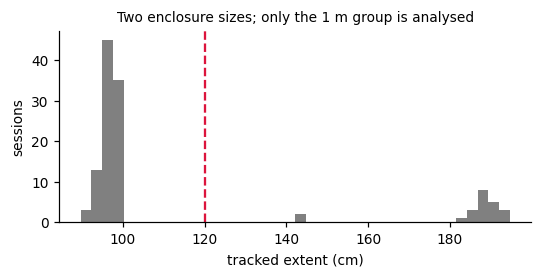

In [5]:
def session_extent(position):
    xy = np.asarray(position.values)
    xy = xy[np.isfinite(xy).all(axis=1)]
    lo, hi = np.percentile(xy, 0.2, axis=0), np.percentile(xy, 99.8, axis=0)
    return float(np.max(0.5 * (hi - lo))) + BIN_SIZE, 0.5 * (lo + hi)


def scan_extents(assets, path="session_extent.json"):
    if os.path.exists(path):
        return json.load(open(path))
    out = []
    for a in tqdm(assets, desc="extent scan"):
        nwb = open_nwb(a["asset_id"])
        d = np.asarray(
            nwb.processing["behavior"]["Position"].spatial_series["SpatialSeriesLED1"].data[:])
        d = d[np.isfinite(d).all(axis=1)]
        lo, hi = np.percentile(d, 0.5, axis=0), np.percentile(d, 99.5, axis=0)
        out.append(dict(path=a["path"], w=float(hi[0] - lo[0]), h=float(hi[1] - lo[1])))
    json.dump(out, open(path, "w"), indent=1)
    return out


extents = scan_extents(assets)
width = np.array([max(e["w"], e["h"]) for e in extents])
std_paths = {e["path"] for e in extents if max(e["w"], e["h"]) < 120}
std_assets = [a for a in assets if a["path"] in std_paths]
print(f"{(width < 120).sum()} sessions near 1 m (median {np.median(width[width < 120]):.0f} cm), "
      f"{(width >= 120).sum()} larger (median {np.median(width[width >= 120]):.0f} cm)")

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.hist(width, bins=40, color="0.5")
ax.axvline(120, color="crimson", ls="--")
ax.set_xlabel("tracked extent (cm)"); ax.set_ylabel("sessions")
ax.set_title("Two enclosure sizes; only the 1 m group is analysed")
fig.tight_layout(); fig.savefig("fig00_box_sizes.png", dpi=140)

## 5. Rate maps

The box is divided into 2.5 cm bins. The spike-count map and the occupancy map
are each smoothed with a 5 cm Gaussian and then divided, which weights every bin
by how well it was sampled (Leutgeb et al. 2007). Bins outside the region the
animal covered are left undefined.

In [6]:
def map_edges(half_width):
    n = int(np.ceil(2 * half_width / BIN_SIZE))
    return np.linspace(-n * BIN_SIZE / 2, n * BIN_SIZE / 2, n + 1)


def occupancy_map(position, dt, edges, center):
    xy = np.asarray(position.values) - center
    occ, _, _ = np.histogram2d(xy[:, 0], xy[:, 1], bins=[edges, edges])
    return occ * dt


def covered_region(occ):
    closed = ndimage.binary_closing(occ > 0, structure=np.ones((3, 3)), iterations=2)
    return ndimage.binary_fill_holes(closed)


def rate_map(spike_xy, occ, edges, sigma=SMOOTH_SIGMA_BINS):
    spk, _, _ = np.histogram2d(spike_xy[:, 0], spike_xy[:, 1], bins=[edges, edges])
    if sigma > 0:
        occ_s = ndimage.gaussian_filter(occ, sigma, mode="constant")
        spk_s = ndimage.gaussian_filter(spk, sigma, mode="constant")
    else:
        occ_s, spk_s = occ, spk
    valid = covered_region(occ) & (occ_s >= MIN_OCCUPANCY)
    with np.errstate(invalid="ignore", divide="ignore"):
        rm = spk_s / occ_s
    rm[~valid] = np.nan
    return rm.T, spk.T, valid.T  # transposed so that rows = y, columns = x


def spike_positions(spike_times, position, center=0.0):
    """Position of the animal at each spike (nearest tracking sample)."""
    t = position.t
    if len(spike_times) == 0:
        return np.empty((0, 2))
    idx = np.clip(np.searchsorted(t, spike_times), 1, len(t) - 1)
    left = np.abs(spike_times - t[idx - 1]) < np.abs(t[idx] - spike_times)
    idx = np.where(left, idx - 1, idx)
    return np.asarray(position.values)[idx] - np.asarray(center)


half, center = session_extent(sess["position"])
edges = map_edges(half)
occ = occupancy_map(sess["position"], sess["dt"], edges, center)
print(f"map {occ.shape}, half-width {half:.1f} cm, "
      f"{covered_region(occ).sum()} bins covered")

map (40, 40), half-width 49.7 cm, 1296 bins covered


The binning is checked against Pynapple's `compute_2d_tuning_curves`, which is
the reference implementation. The maps agree exactly on the unsmoothed version;
the hand-rolled function is used from here on because it is also called tens of
thousands of times inside the shuffling control.

In [7]:
centred = nap.TsdFrame(t=sess["position"].t,
                       d=np.asarray(sess["position"].values) - center,
                       columns=["x", "y"], time_support=sess["position"].time_support)
tc_ref, _ = nap.compute_2d_tuning_curves(
    sess["units"], centred, nb_bins=len(edges) - 1, ep=sess["run_ep"],
    minmax=(edges[0], edges[-1], edges[0], edges[-1]))
for u in list(sess["units"].keys())[:5]:
    st = np.asarray(sess["units"][u].restrict(sess["run_ep"]).t)
    mine = rate_map(spike_positions(st, sess["position"], center), occ, edges, sigma=0)[0]
    ref = np.asarray(tc_ref[u]).T
    ok = np.isfinite(mine) & np.isfinite(ref)
    print(f"unit {u}: r = {np.corrcoef(mine[ok], ref[ok])[0, 1]:.4f}, "
          f"max |difference| = {np.nanmax(np.abs(mine[ok] - ref[ok])):.2e} Hz")

unit 0: r = 1.0000, max |difference| = 6.26e-11 Hz
unit 1: r = 1.0000, max |difference| = 3.54e-11 Hz
unit 2: r = 1.0000, max |difference| = 2.93e-11 Hz
unit 3: r = 1.0000, max |difference| = 3.19e-11 Hz
unit 4: r = 1.0000, max |difference| = 1.86e-11 Hz


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_2d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


## 6. Autocorrelogram and gridness score

The spatial autocorrelogram is the Pearson correlation between the rate map and
a copy of itself displaced by every possible spatial lag, computed over the
overlapping defined bins only (Sargolini et al. 2006). Six FFT-based
correlations give all the sums needed, so the whole surface costs a few
milliseconds.

The gridness score takes the annulus of the autocorrelogram that excludes the
central peak, rotates it, and compares. A hexagonal pattern is unchanged by 60
and 120 degree rotations and maximally mismatched at 30, 90 and 150 degrees, so

$$g = \min(r_{60}, r_{120}) - \max(r_{30}, r_{90}, r_{150}),$$

maximised over a range of outer radii. Values above about 0.3 to 0.5 are
conventionally taken as grid-like; the threshold used below is derived from the
data by shuffling rather than assumed.

In [8]:
def _corr_full(a, b):
    return fftconvolve(a, b[::-1, ::-1], mode="full")


def autocorrelogram(rm):
    m = np.isfinite(rm).astype(float)
    a = np.where(np.isfinite(rm), rm, 0.0)
    n = _corr_full(m, m)
    num = n * _corr_full(a, a) - _corr_full(a, m) * _corr_full(m, a)
    d1 = n * _corr_full(a * a, m) - _corr_full(a, m) ** 2
    d2 = n * _corr_full(m, a * a) - _corr_full(m, a) ** 2
    with np.errstate(invalid="ignore", divide="ignore"):
        r = num / np.sqrt(np.clip(d1, 0, None) * np.clip(d2, 0, None))
    r[n < MIN_OVERLAP_BINS] = np.nan
    return np.clip(r, -1, 1)


def crosscorrelogram(a_map, b_map):
    ma, mb = np.isfinite(a_map).astype(float), np.isfinite(b_map).astype(float)
    a, b = np.where(ma > 0, a_map, 0.0), np.where(mb > 0, b_map, 0.0)
    n = _corr_full(ma, mb)
    num = n * _corr_full(a, b) - _corr_full(a, mb) * _corr_full(ma, b)
    d1 = n * _corr_full(a * a, mb) - _corr_full(a, mb) ** 2
    d2 = n * _corr_full(ma, b * b) - _corr_full(ma, b) ** 2
    with np.errstate(invalid="ignore", divide="ignore"):
        r = num / np.sqrt(np.clip(d1, 0, None) * np.clip(d2, 0, None))
    r[n < MIN_OVERLAP_BINS] = np.nan
    return np.clip(r, -1, 1)


def _radius_grid(shape):
    cy, cx = (shape[0] - 1) / 2.0, (shape[1] - 1) / 2.0
    yy, xx = np.mgrid[0:shape[0], 0:shape[1]]
    return np.hypot(yy - cy, xx - cx)


def central_peak_radius(ac):
    """Inner edge of the annulus: where the radial profile stops falling."""
    rad = _radius_grid(ac.shape)
    rs = np.arange(0, min(ac.shape) // 2)
    prof = np.array([np.nanmean(ac[(rad >= r) & (rad < r + 1)]) for r in rs])
    prof = np.where(np.isfinite(prof), prof, 0.0)
    turn = np.flatnonzero(np.diff(prof) > 0)
    return max(float(rs[turn[0]]) if turn.size else 3.0, 2.0)


def gridness_score(ac, return_detail=False):
    rad = _radius_grid(ac.shape)
    r_in = central_peak_radius(ac)
    r_max = min(ac.shape) / 2.0 - 1
    if r_max <= r_in + 4:
        return (np.nan, np.nan, np.nan, {}) if return_detail else np.nan
    filled = np.where(np.isfinite(ac), ac, 0.0)
    valid = np.isfinite(ac)
    rots = {ang: (ndimage.rotate(filled, ang, reshape=False, order=1, mode="constant"),
                  ndimage.rotate(valid.astype(float), ang, reshape=False, order=1,
                                 mode="constant") > 0.9)
            for ang in (30, 60, 90, 120, 150)}
    best, best_r, best_detail = -np.inf, np.nan, {}
    for r_out in np.arange(r_in + 4, r_max + 0.01, 1.0):
        base = (rad >= r_in) & (rad <= r_out) & valid
        if base.sum() < 50:
            continue
        cors = {}
        for ang, (rot, rvalid) in rots.items():
            m = base & rvalid
            if m.sum() < 50:
                cors = {}
                break
            cors[ang] = float(np.corrcoef(ac[m], rot[m])[0, 1])
        if not cors:
            continue
        g = min(cors[60], cors[120]) - max(cors[30], cors[90], cors[150])
        if g > best:
            best, best_r, best_detail = g, r_out, cors
    if not np.isfinite(best):
        return (np.nan, np.nan, np.nan, {}) if return_detail else np.nan
    return (best, r_in, best_r, best_detail) if return_detail else best


def autocorr_peaks(ac, min_distance=2):
    a = np.where(np.isfinite(ac), ac, -np.inf)
    peaks = (a == ndimage.maximum_filter(a, size=2 * min_distance + 1)) & \
            np.isfinite(ac) & (ac > 0.1)
    ys, xs = np.nonzero(peaks)
    cy, cx = (ac.shape[0] - 1) / 2.0, (ac.shape[1] - 1) / 2.0
    order = np.argsort(np.hypot(ys - cy, xs - cx))
    return ys[order], xs[order], np.hypot(ys - cy, xs - cx)[order]


def grid_geometry(ac, r_in=None):
    """Spacing (cm) and orientation (deg) from the six closest non-central peaks."""
    if r_in is None:
        r_in = central_peak_radius(ac)
    ys, xs, d = autocorr_peaks(ac)
    cy, cx = (ac.shape[0] - 1) / 2.0, (ac.shape[1] - 1) / 2.0
    keep = d >= max(r_in, 3.0)
    ys, xs, d = ys[keep], xs[keep], d[keep]
    if len(d) < 3:
        return np.nan, np.nan, 0
    n = min(6, len(d))
    ang = np.degrees(np.arctan2(ys[:n] - cy, xs[:n] - cx)) % 180
    return float(np.median(d[:n]) * BIN_SIZE), float(np.min(ang % 60)), n


def spatial_information(rm, occ_map):
    """Skaggs information in bits per spike."""
    valid = np.isfinite(rm) & (occ_map.T > 0)
    lam, p = rm[valid], occ_map.T[valid]
    p = p / p.sum()
    mean_rate = np.sum(p * lam)
    if mean_rate <= 0:
        return np.nan
    nz = lam > 0
    return float(np.sum(p[nz] * (lam[nz] / mean_rate) * np.log2(lam[nz] / mean_rate)))


def analyze_unit(spike_times, position, occ, edges, center):
    sxy = spike_positions(spike_times, position, center)
    rm, spk, valid = rate_map(sxy, occ, edges)
    ac = autocorrelogram(rm)
    g, r_in, r_out, cors = gridness_score(ac, return_detail=True)
    spacing, orient, npk = grid_geometry(ac, r_in=r_in)
    return dict(spike_xy=sxy, rate_map=rm, autocorr=ac, gridness=g, r_in=r_in, r_out=r_out,
                rot_corr=cors, spacing=spacing, orientation=orient, n_peaks=npk,
                peak_rate=float(np.nanmax(rm)) if np.isfinite(rm).any() else np.nan,
                mean_rate=float(np.nansum(spk) / occ.sum()) if occ.sum() > 0 else np.nan,
                spatial_info=spatial_information(rm, occ))

A worked example. The unit below fires in a lattice of fields, and the rotational
correlations behave exactly as a hexagon should: high at 60 and 120 degrees,
negative at 30, 90 and 150.

unit t3c2, 2418 spikes, peak 19.5 Hz
gridness 1.48, spacing 43 cm, orientation 24 deg
rotational correlations: {30: -0.59, 60: 0.9, 90: -0.63, 120: 0.9, 150: -0.58}


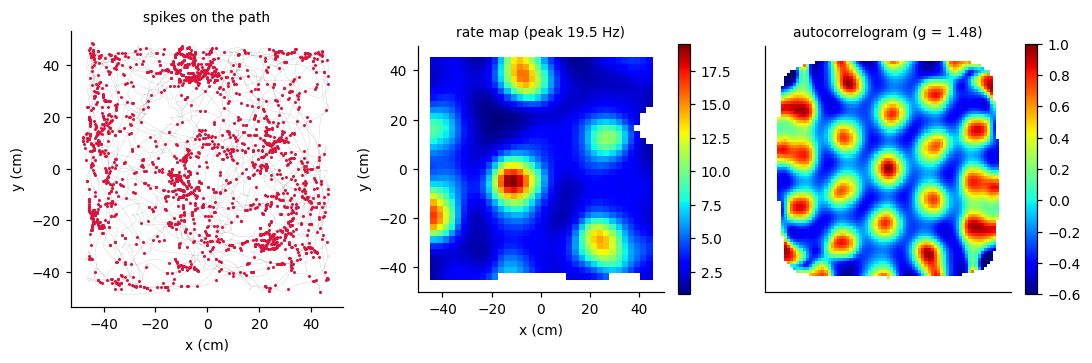

In [9]:
DEMO_UNIT = "t3c2"
names = [str(n) for n in sess["units"].unit_name]
demo_id = list(sess["units"].keys())[names.index(DEMO_UNIT)]
demo_spikes = np.asarray(sess["units"][demo_id].restrict(sess["run_ep"]).t)
demo = analyze_unit(demo_spikes, sess["position"], occ, edges, center)
print(f"unit {DEMO_UNIT}, {len(demo_spikes)} spikes, peak {demo['peak_rate']:.1f} Hz")
print(f"gridness {demo['gridness']:.2f}, spacing {demo['spacing']:.0f} cm, "
      f"orientation {demo['orientation']:.0f} deg")
print("rotational correlations:", {k: round(v, 2) for k, v in demo["rot_corr"].items()})

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
traj = np.asarray(sess["position"].values) - center
axes[0].plot(traj[:, 0], traj[:, 1], lw=0.2, color="0.75")
axes[0].plot(demo["spike_xy"][:, 0], demo["spike_xy"][:, 1], ".", ms=2, color="crimson")
axes[0].set_aspect("equal"); axes[0].set_title("spikes on the path")
axes[0].set_xlabel("x (cm)"); axes[0].set_ylabel("y (cm)")
im = axes[1].imshow(demo["rate_map"], origin="lower", cmap="jet",
                    extent=[edges[0], edges[-1]] * 2)
axes[1].set_xlabel("x (cm)"); axes[1].set_ylabel("y (cm)")
axes[1].set_title(f"rate map (peak {demo['peak_rate']:.1f} Hz)")
plt.colorbar(im, ax=axes[1], fraction=0.046)
im = axes[2].imshow(demo["autocorr"], origin="lower", cmap="jet", vmin=-0.6, vmax=1)
axes[2].set_title(f"autocorrelogram (g = {demo['gridness']:.2f})")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
fig.tight_layout(); fig.savefig("fig0a_worked_example.png", dpi=140)

## 7. Head direction

The same session also supports a head-direction tuning curve, which is needed
later to identify conjunctive cells.

In [10]:
def hd_tuning(spike_times, hd, nbins=36):
    edges_a = np.linspace(0, 2 * np.pi, nbins + 1)
    t = hd.t
    dt = float(np.median(np.diff(t)))
    occ_a = np.histogram(np.asarray(hd.values), bins=edges_a)[0] * dt
    idx = np.clip(np.searchsorted(t, spike_times), 0, len(t) - 1)
    ok = np.abs(t[idx] - spike_times) < 0.05
    cnt = np.histogram(np.asarray(hd.values)[idx[ok]], bins=edges_a)[0]
    with np.errstate(invalid="ignore", divide="ignore"):
        tc = cnt / occ_a
    tc[occ_a < 0.5] = np.nan
    return 0.5 * (edges_a[1:] + edges_a[:-1]), tc


def mean_vector_length(centers, tc):
    ok = np.isfinite(tc) & (tc > 0)
    if ok.sum() < 5 or tc[ok].sum() == 0:
        return np.nan, np.nan
    v = np.sum(tc[ok] * np.exp(1j * centers[ok])) / np.sum(tc[ok])
    return float(np.abs(v)), float(np.angle(v) % (2 * np.pi))

## 8. Shuffling control

A hexagonal autocorrelogram has to be tested against the possibility that it
arises from the trajectory plus the cell's burstiness alone. The standard
control shifts the whole spike train in time by a random offset of at least 20 s
and wraps it around the session. This preserves the number of spikes and the
fine temporal structure of the train but destroys the relationship between
spikes and position.

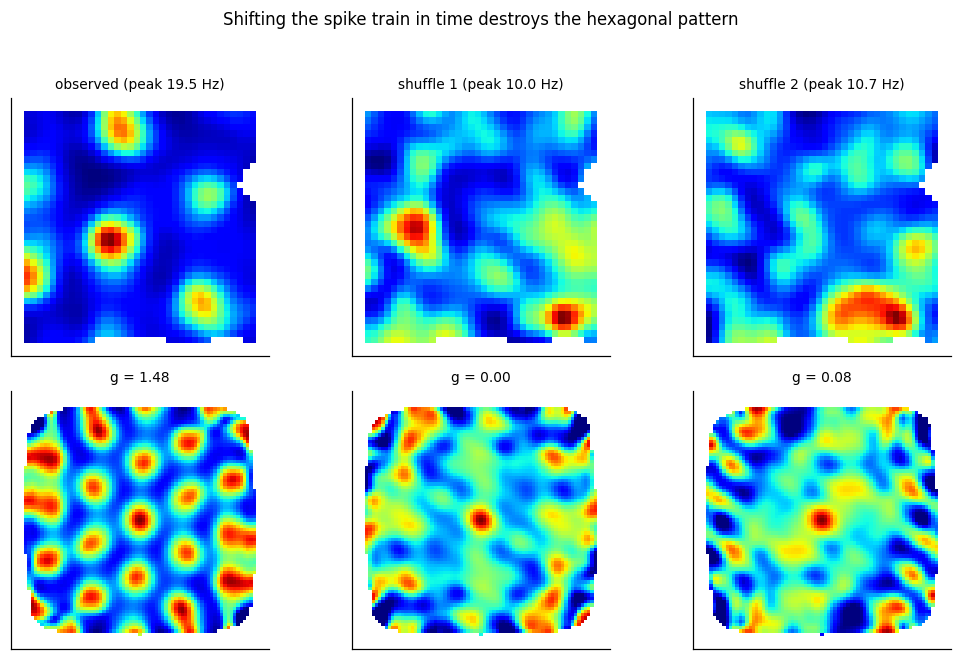

In [11]:
def shift_spikes(spike_times, t0, t1, shift):
    return t0 + np.mod(spike_times - t0 + shift, t1 - t0)


rng = np.random.default_rng(1)
t_start, t_end = float(sess["run_ep"].start[0]), float(sess["run_ep"].end[-1])
fig, axes = plt.subplots(2, 3, figsize=(9.5, 6))
for j in range(3):
    if j == 0:
        r, lab = demo, "observed"
    else:
        st = np.sort(shift_spikes(demo_spikes, t_start, t_end,
                                  rng.uniform(MIN_SHIFT, t_end - t_start - MIN_SHIFT)))
        r, lab = analyze_unit(st, sess["position"], occ, edges, center), f"shuffle {j}"
    axes[0, j].imshow(r["rate_map"], origin="lower", cmap="jet")
    axes[0, j].set_title(f"{lab} (peak {r['peak_rate']:.1f} Hz)")
    axes[1, j].imshow(r["autocorr"], origin="lower", cmap="jet", vmin=-0.6, vmax=1)
    axes[1, j].set_title(f"g = {r['gridness']:.2f}")
    for a in (axes[0, j], axes[1, j]):
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Shifting the spike train in time destroys the hexagonal pattern", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96]); fig.savefig("fig0b_shuffle_example.png", dpi=140)

## 9. Running the analysis over all 96 one-metre sessions

Each unit gets a rate map, an autocorrelogram, a gridness score, grid geometry,
spatial information, a head-direction tuning curve where available, and 200
shuffles. Each session is also split into halves so that the two rate maps can be
correlated, which tests whether the pattern is stable within the session.

The loop below writes `unit_metrics.csv`, `shuffle_gridness.npy`, `maps.npz` and
`unit_stability.csv`, and reuses them if they already exist. The modular scripts
`02_run_analysis.py` and `02b_stability.py` in this directory run exactly the
same computation across processes, which is how the shipped results were
produced.

In [12]:
def run_session(asset):
    d = load_session(asset["asset_id"])
    pos, ep = d["position"], d["run_ep"]
    half, center = session_extent(pos)
    edges = map_edges(half)
    occ = occupancy_map(pos, d["dt"], edges, center)
    t0, t1 = float(ep.start[0]), float(ep.end[-1])
    mid = 0.5 * (t0 + t1)
    halves = [ep.intersect(nap.IntervalSet(start=t0, end=mid)),
              ep.intersect(nap.IntervalSet(start=mid, end=t1))]
    half_pos = [pos.restrict(h) for h in halves]
    half_occ = [occupancy_map(p, d["dt"], edges, center) for p in half_pos]
    rng = np.random.default_rng(abs(hash(asset["path"])) % (2 ** 31) + SEED)

    rows, shuffles, maps = [], [], {}
    for i, u in enumerate(d["units"]):
        st = np.asarray(d["units"][u].restrict(ep).t)
        key = f"{asset['path']}|{d['units'].unit_name[i]}"
        row = dict(path=asset["path"], subject=d["subject"],
                   session=asset["path"].split("ses-")[1][:8],
                   unit=str(d["units"].unit_name[i]), layer=str(d["units"].histology[i]),
                   depth_mm=float(d["units"].depth[i]) * 1000.0, n_spikes=len(st),
                   box_half_cm=half, run_time_s=float(ep.tot_length()))
        if len(st) < MIN_SPIKES:
            rows.append({**row, "included": False, "gridness": np.nan})
            shuffles.append(np.full(N_SHUFFLE, np.nan))
            continue

        r = analyze_unit(st, pos, occ, edges, center)
        row.update(included=True, gridness=r["gridness"], spacing_cm=r["spacing"],
                   orientation_deg=r["orientation"], peak_rate=r["peak_rate"],
                   mean_rate=r["mean_rate"], spatial_info=r["spatial_info"])

        if d["hd"] is not None:
            c, tc = hd_tuning(st, d["hd"])
            mvl, pref = mean_vector_length(c, tc)
            row.update(hd_mvl=mvl, hd_pref=pref)
            maps[key + "|hdtc"] = tc
        else:
            row.update(hd_mvl=np.nan, hd_pref=np.nan)

        sg, hd_sh = np.empty(N_SHUFFLE), np.empty(N_SHUFFLE)
        for k in range(N_SHUFFLE):
            sst = np.sort(shift_spikes(st, t0, t1,
                                       rng.uniform(MIN_SHIFT, t1 - t0 - MIN_SHIFT)))
            sxy = spike_positions(sst, pos, center)
            sg[k] = gridness_score(autocorrelogram(rate_map(sxy, occ, edges)[0]))
            hd_sh[k] = (mean_vector_length(*hd_tuning(sst, d["hd"]))[0]
                        if d["hd"] is not None else np.nan)
        shuffles.append(sg)
        row["gridness_p"] = float(np.mean(sg >= r["gridness"]))
        row["gridness_shuf_95"] = float(np.nanpercentile(sg, 95))
        row["hd_mvl_shuf_95"] = (float(np.nanpercentile(hd_sh, 95))
                                 if d["hd"] is not None else np.nan)
        row["hd_p"] = float(np.nanmean(hd_sh >= row["hd_mvl"])) if d["hd"] is not None else np.nan

        # split-half stability
        hm = [analyze_unit(np.asarray(d["units"][u].restrict(h).t), p, o, edges, center)
              for h, p, o in zip(halves, half_pos, half_occ)]
        ok = np.isfinite(hm[0]["rate_map"]) & np.isfinite(hm[1]["rate_map"])
        row["stability_r"] = (float(np.corrcoef(hm[0]["rate_map"][ok],
                                                hm[1]["rate_map"][ok])[0, 1])
                              if ok.sum() > 50 else np.nan)
        rows.append(row)
        maps[key + "|rm"] = r["rate_map"].astype(np.float32)
        maps[key + "|ac"] = r["autocorr"].astype(np.float32)
        maps[key + "|sxy"] = r["spike_xy"].astype(np.float32)
    maps[asset["path"] + "|traj"] = (np.asarray(pos.values) - center).astype(np.float32)
    return rows, np.array(shuffles), maps


CACHED = all(os.path.exists(f) for f in
             ["unit_metrics.csv", "shuffle_gridness.npy", "maps.npz", "unit_stability.csv"])
if CACHED:
    df = pd.read_csv("unit_metrics.csv")
    shuf = np.load("shuffle_gridness.npy")
    maps = dict(np.load("maps.npz"))
    if "stability_r" not in df.columns:
        df = df.merge(pd.read_csv("unit_stability.csv")[["path", "unit", "stability_r"]],
                      on=["path", "unit"], how="left")
    print("loaded cached results")
else:
    all_rows, all_shuf, maps = [], [], {}
    for a in tqdm(std_assets, desc="sessions"):
        rows, s, m = run_session(a)
        all_rows += rows
        all_shuf.append(s)
        maps.update(m)
    df = pd.DataFrame(all_rows)
    shuf = np.concatenate(all_shuf, axis=0)
    df.to_csv("unit_metrics.csv", index=False)
    np.save("shuffle_gridness.npy", shuf)
    np.savez_compressed("maps.npz", **maps)
    df[["path", "unit", "stability_r"]].to_csv("unit_stability.csv", index=False)

inc = df["included"].fillna(False).values
THRESH = float(np.nanpercentile(shuf[inc].ravel(), 95))
df["is_grid"] = inc & (df["gridness"] > THRESH)
df["is_hd"] = inc & (df["hd_mvl"] > df["hd_mvl_shuf_95"])
df["is_conj"] = df["is_grid"] & df["is_hd"]
df.to_csv("unit_metrics_classified.csv", index=False)

print(f"{int(inc.sum())} units from {df.path.nunique()} sessions and "
      f"{df.subject.nunique()} rats")
print(f"gridness threshold (95th percentile of {shuf[inc].size:,} shuffles) = {THRESH:.3f}")
print(f"grid cells: {int(df.is_grid.sum())} ({100 * df.is_grid.mean():.1f}%)")

loaded cached results
468 units from 96 sessions and 15 rats
gridness threshold (95th percentile of 93,600 shuffles) = 0.665
grid cells: 133 (28.4%)


## 10. Results

### 10.1 Raw data from one session

Position, running speed, the spike trains of every unit, and the firing rate of
one grid cell. The shading marks the times the animal was inside one of that
cell's firing fields; almost every burst falls inside a field.

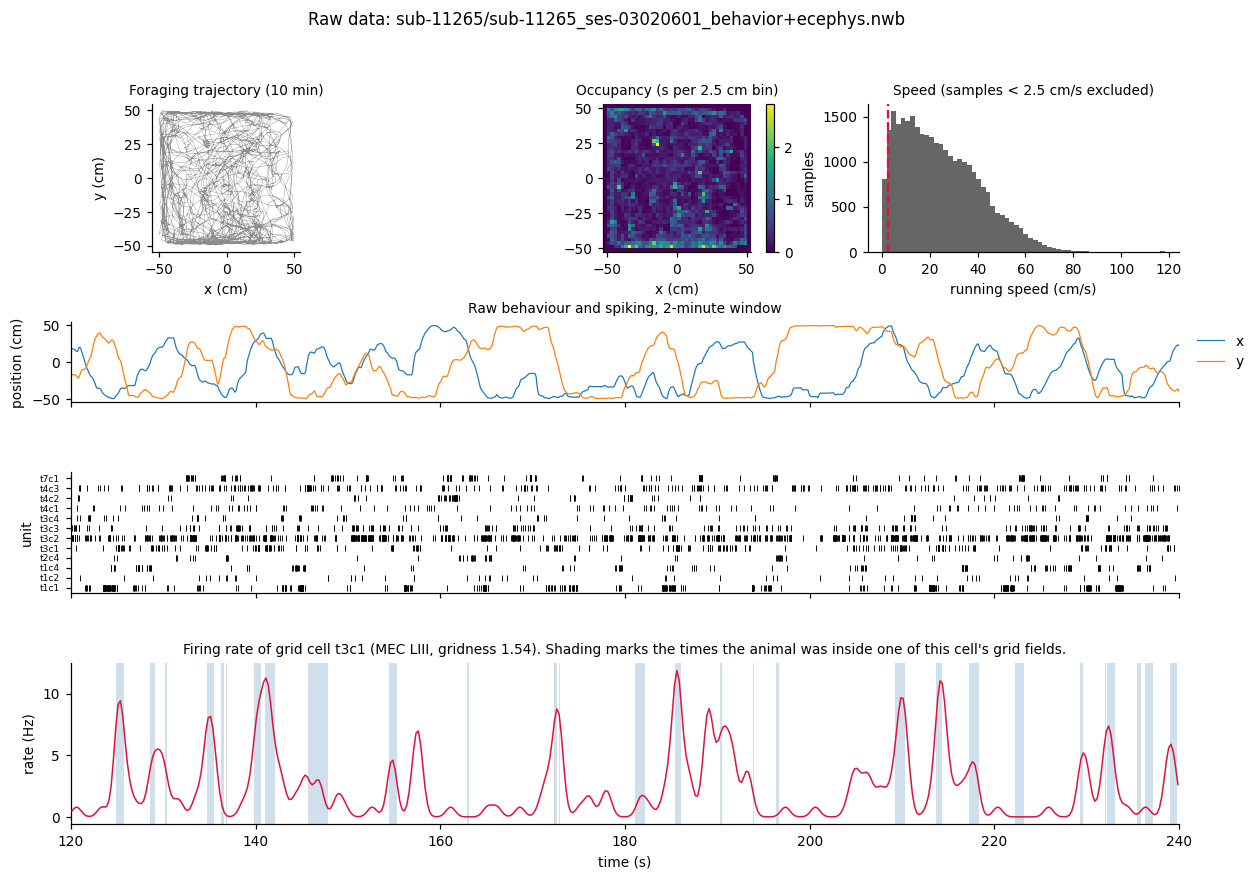

In [13]:
def key_of(row, suf):
    return f"{row['path']}|{row['unit']}|{suf}"


def show_map(ax, m, title, cmap="jet", extent=None):
    im = ax.imshow(m, origin="lower", cmap=cmap, vmin=0, vmax=np.nanmax(m),
                   extent=extent, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, pad=3)
    return im


ex = df[df.is_grid].sort_values("gridness", ascending=False).iloc[0]
d = load_session([a for a in assets if a["path"] == ex["path"]][0]["asset_id"])
half_e, center_e = session_extent(d["position"])
edges_e = map_edges(half_e)
occ_e = occupancy_map(d["position"], d["dt"], edges_e, center_e)
xy = np.asarray(d["position_all"].values) - center_e
t = d["position_all"].t

fig = plt.figure(figsize=(13, 8.5))
gs = fig.add_gridspec(4, 3, height_ratios=[1.1, 0.6, 0.9, 1.2], hspace=0.55, wspace=0.28)
ax = fig.add_subplot(gs[0, 0])
ax.plot(xy[:, 0], xy[:, 1], lw=0.25, color="0.55")
ax.set_aspect("equal"); ax.set_title("Foraging trajectory (10 min)")
ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(occ_e.T, origin="lower", extent=[edges_e[0], edges_e[-1]] * 2, cmap="viridis")
ax.set_title("Occupancy (s per 2.5 cm bin)"); ax.set_xlabel("x (cm)")
plt.colorbar(im, ax=ax, fraction=0.046)
ax = fig.add_subplot(gs[0, 2])
sp = np.asarray(d["speed"].values)
ax.hist(sp[np.isfinite(sp)], bins=60, color="0.4")
ax.axvline(SPEED_THRESH, color="crimson", ls="--")
ax.set_xlabel("running speed (cm/s)"); ax.set_ylabel("samples")
ax.set_title(f"Speed (samples < {SPEED_THRESH} cm/s excluded)")

win = nap.IntervalSet(start=t[0] + 120, end=t[0] + 240)
ax = fig.add_subplot(gs[1, :])
p = d["position_all"].restrict(win)
ax.plot(p.t, np.asarray(p.values)[:, 0] - center_e[0], label="x", lw=0.8)
ax.plot(p.t, np.asarray(p.values)[:, 1] - center_e[1], label="y", lw=0.8)
ax.legend(loc="upper left", bbox_to_anchor=(1.005, 1.0), frameon=False)
ax.set_ylabel("position (cm)"); ax.set_title("Raw behaviour and spiking, 2-minute window")
ax.set_xlim(win.start[0], win.end[0]); ax.set_xticklabels([])

ax = fig.add_subplot(gs[2, :])
for j, u in enumerate(d["units"]):
    st = np.asarray(d["units"][u].restrict(win).t)
    ax.plot(st, np.full_like(st, j), "|", ms=4, color="k", mew=0.6)
ax.set_ylabel("unit"); ax.set_yticks(range(len(d["units"])))
ax.set_yticklabels([str(n) for n in d["units"].unit_name], fontsize=6)
ax.set_xlim(win.start[0], win.end[0]); ax.set_xticklabels([])

ax = fig.add_subplot(gs[3, :])
ui = list(d["units"].keys())[
    [str(n) for n in d["units"].unit_name].index(ex["unit"])]
rate = (d["units"][ui].count(0.25, win) / 0.25).smooth(0.5)
ax.plot(rate.t, np.asarray(rate.values), color="crimson", lw=1, zorder=3)
rm_ex = analyze_unit(np.asarray(d["units"][ui].restrict(d["run_ep"]).t),
                     d["position"], occ_e, edges_e, center_e)["rate_map"]
field = rm_ex > 0.4 * np.nanmax(rm_ex)
pxy = np.asarray(p.values) - center_e
ix = np.clip(np.digitize(pxy[:, 0], edges_e) - 1, 0, len(edges_e) - 2)
iy = np.clip(np.digitize(pxy[:, 1], edges_e) - 1, 0, len(edges_e) - 2)
ed = np.diff(np.concatenate([[0], field[iy, ix].astype(int), [0]]))
for s, e in zip(np.flatnonzero(ed == 1), np.flatnonzero(ed == -1) - 1):
    ax.axvspan(p.t[s], p.t[e], color="steelblue", alpha=0.25, lw=0)
ax.set_xlabel("time (s)"); ax.set_ylabel("rate (Hz)")
ax.set_title(f"Firing rate of grid cell {ex['unit']} ({ex['layer']}, gridness "
             f"{ex['gridness']:.2f}). Shading marks the times the animal was inside "
             f"one of this cell's grid fields.")
ax.set_xlim(win.start[0], win.end[0])
fig.suptitle(f"Raw data: {ex['path']}", y=0.98)
fig.savefig("fig01_raw_session.png", dpi=140, bbox_inches="tight")

### 10.2 Example grid cells

Six grid cells from four rats and three MEC layers, each shown as spikes on the
animal's path, the rate map, and the autocorrelogram.

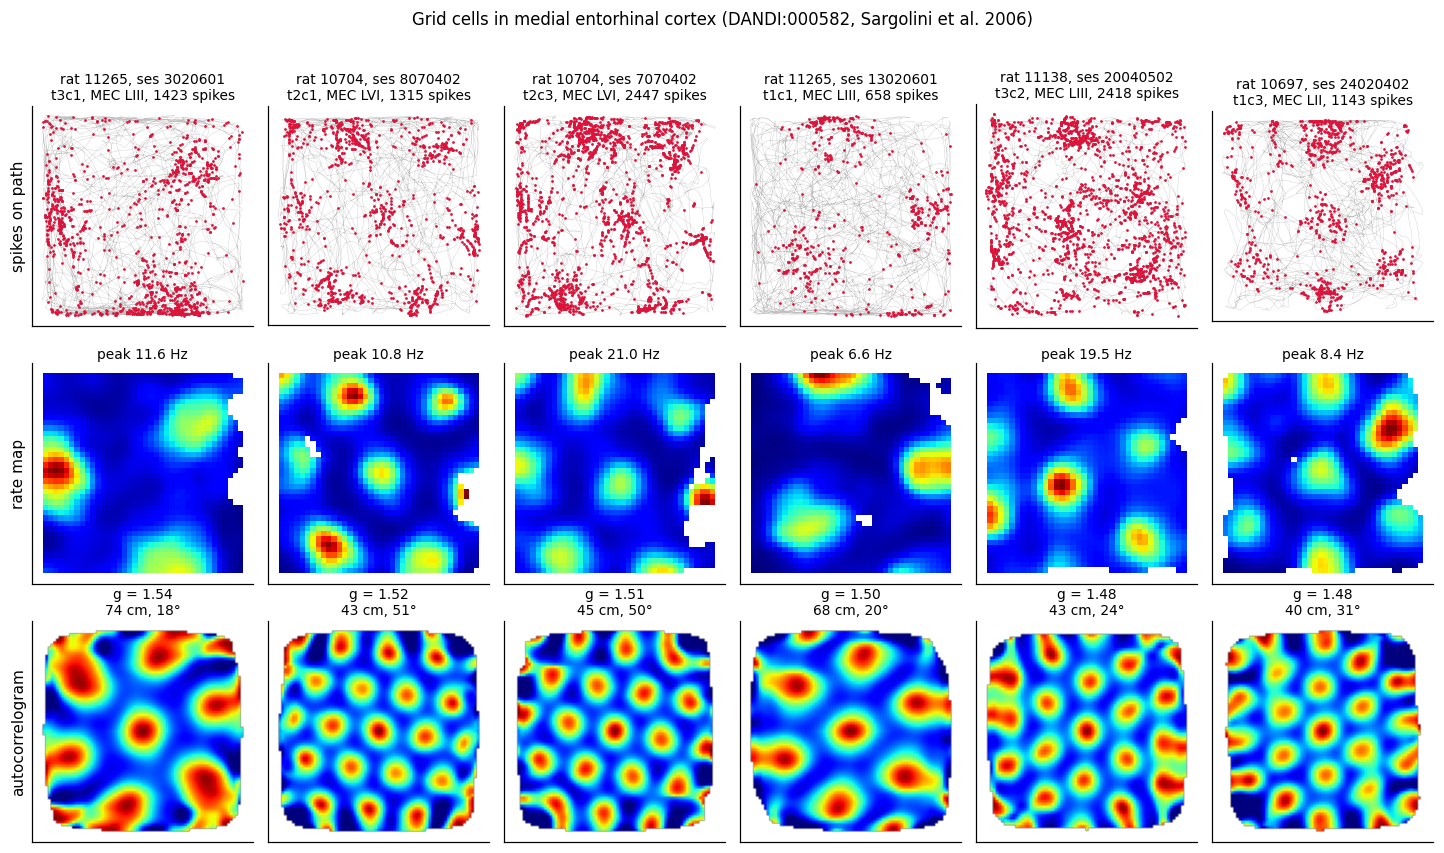

In [14]:
sel = df[df.is_grid & (df.n_spikes >= 500) & (df.stability_r >= 0.5)]
sel = sel.sort_values("gridness", ascending=False)
picked, seen = [], {}
for _, r in sel.iterrows():
    if seen.get(r["subject"], 0) < 2:
        picked.append(r); seen[r["subject"]] = seen.get(r["subject"], 0) + 1
    if len(picked) == 6:
        break

fig, axes = plt.subplots(3, 6, figsize=(13.2, 7.8))
for j, r in enumerate(picked):
    traj = maps[r["path"] + "|traj"]
    sxy = maps[key_of(r, "sxy")]
    axes[0, j].plot(traj[:, 0], traj[:, 1], lw=0.2, color="0.75")
    axes[0, j].plot(sxy[:, 0], sxy[:, 1], ".", ms=1.6, color="crimson")
    axes[0, j].set_aspect("equal"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[0, j].set_title(f"rat {r['subject']}, ses {r['session']}\n{r['unit']}, "
                         f"{r['layer']}, {r['n_spikes']} spikes", pad=4)
    show_map(axes[1, j], maps[key_of(r, "rm")], f"peak {r['peak_rate']:.1f} Hz")
    axes[2, j].imshow(maps[key_of(r, "ac")], origin="lower", cmap="jet", vmin=-0.6, vmax=1)
    axes[2, j].set_xticks([]); axes[2, j].set_yticks([])
    axes[2, j].set_title(f"g = {r['gridness']:.2f}\n{r['spacing_cm']:.0f} cm, "
                         f"{r['orientation_deg']:.0f}°", pad=4)
for lab, row in zip(["spikes on path", "rate map", "autocorrelogram"], range(3)):
    axes[row, 0].set_ylabel(lab, fontsize=10)
fig.suptitle("Grid cells in medial entorhinal cortex (DANDI:000582, "
             "Sargolini et al. 2006)", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96], h_pad=2.2)
fig.savefig("fig02_example_grid_cells.png", dpi=140)

### 10.3 The population result

The observed gridness distribution has a heavy right tail that the shuffled null
does not: 28% of units exceed the 95th percentile of the shuffled scores, almost
six times the 5% expected by construction. Grid cells are commonest in the
superficial layers, and their maps are far more reproducible between the two
halves of a session than those of other units.

split-half stability, grid vs other: p = 3.14e-18


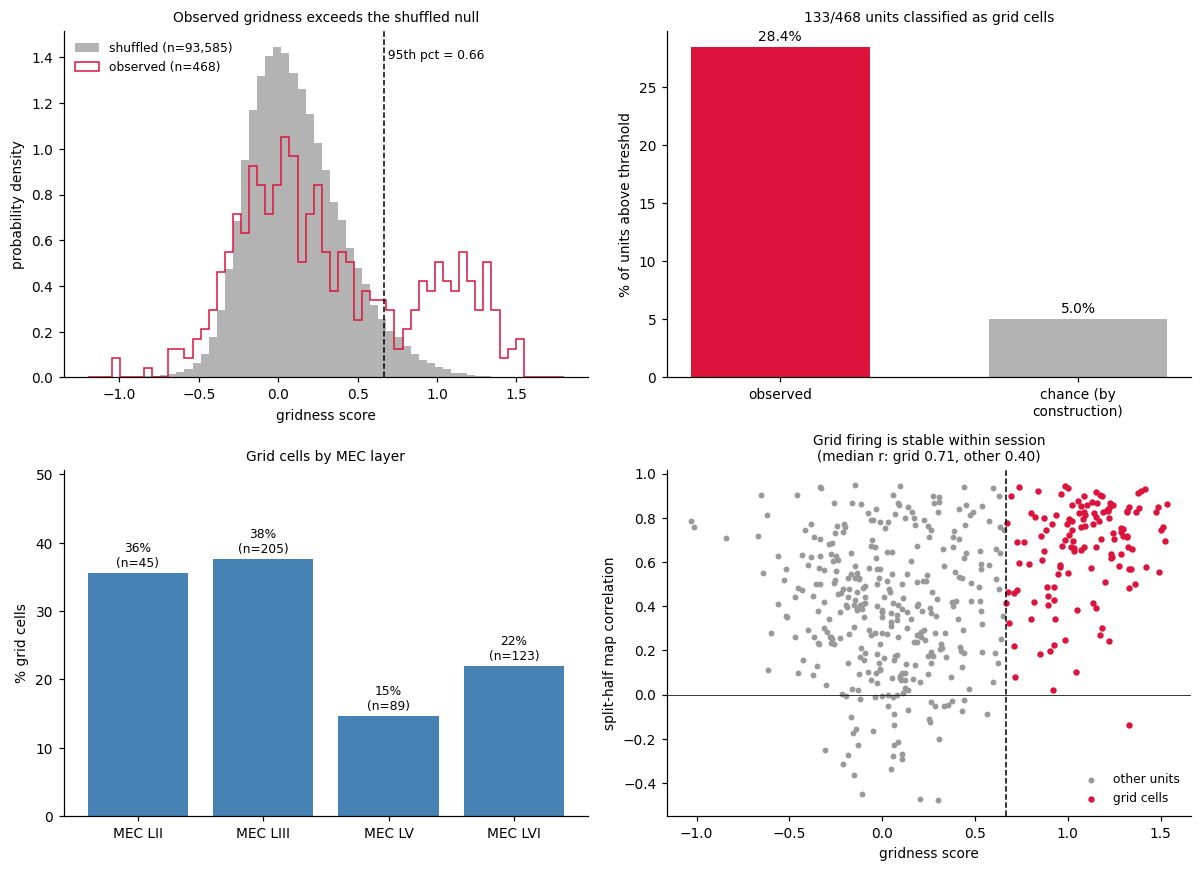

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
obs = df.loc[inc, "gridness"].values
null = shuf[inc].ravel()
null = null[np.isfinite(null)]
ax = axes[0, 0]
bins = np.linspace(-1.2, 1.8, 60)
ax.hist(null, bins=bins, density=True, color="0.7", label=f"shuffled (n={null.size:,})")
ax.hist(obs, bins=bins, density=True, histtype="step", lw=1.8, color="crimson",
        label=f"observed (n={len(obs)})")
ax.axvline(THRESH, color="k", ls="--", lw=1)
ax.text(THRESH, ax.get_ylim()[1] * 0.92, f" 95th pct = {THRESH:.2f}", fontsize=8)
ax.set_xlabel("gridness score"); ax.set_ylabel("probability density")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Observed gridness exceeds the shuffled null")

ax = axes[0, 1]
frac_obs = float(np.mean(obs > THRESH))
ax.bar([0, 1], [frac_obs * 100, 5], color=["crimson", "0.7"], width=0.6)
ax.set_xticks([0, 1]); ax.set_xticklabels(["observed", "chance (by\nconstruction)"])
ax.set_ylabel("% of units above threshold")
ax.set_title(f"{int(df.is_grid.sum())}/{int(inc.sum())} units classified as grid cells")
for x, v in zip([0, 1], [frac_obs * 100, 5]):
    ax.text(x, v + 0.6, f"{v:.1f}%", ha="center", fontsize=9)

ax = axes[1, 0]
layers = ["MEC LII", "MEC LIII", "MEC LV", "MEC LVI"]
frac = df[inc & df.layer.isin(layers)].groupby("layer")["is_grid"].agg(
    ["mean", "count"]).reindex(layers)
ax.bar(range(len(layers)), frac["mean"] * 100, color="steelblue")
for i, (m, c) in enumerate(zip(frac["mean"], frac["count"])):
    ax.text(i, m * 100 + 1, f"{m * 100:.0f}%\n(n={int(c)})", ha="center", fontsize=8)
ax.set_xticks(range(len(layers))); ax.set_xticklabels(layers)
ax.set_ylabel("% grid cells"); ax.set_title("Grid cells by MEC layer")
ax.set_ylim(0, max(frac["mean"] * 100) * 1.35)

ax = axes[1, 1]
g_, ng = df[df.is_grid], df[inc & ~df.is_grid]
ax.scatter(ng["gridness"], ng["stability_r"], s=8, color="0.6", label="other units")
ax.scatter(g_["gridness"], g_["stability_r"], s=10, color="crimson", label="grid cells")
ax.axvline(THRESH, color="k", ls="--", lw=1); ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("gridness score"); ax.set_ylabel("split-half map correlation")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title(f"Grid firing is stable within session\n(median r: grid "
             f"{g_['stability_r'].median():.2f}, other {ng['stability_r'].median():.2f})")
fig.tight_layout(); fig.savefig("fig03_gridness_population.png", dpi=140)

u_stat, p_stab = stats.mannwhitneyu(g_["stability_r"].dropna(), ng["stability_r"].dropna())
print(f"split-half stability, grid vs other: p = {p_stab:.2e}")

### 10.4 Grid geometry

Spacing and orientation of the identified grids, and how they relate to layer,
electrode depth and firing rate.

/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_43274/1112858011.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=layers, showfliers=False)


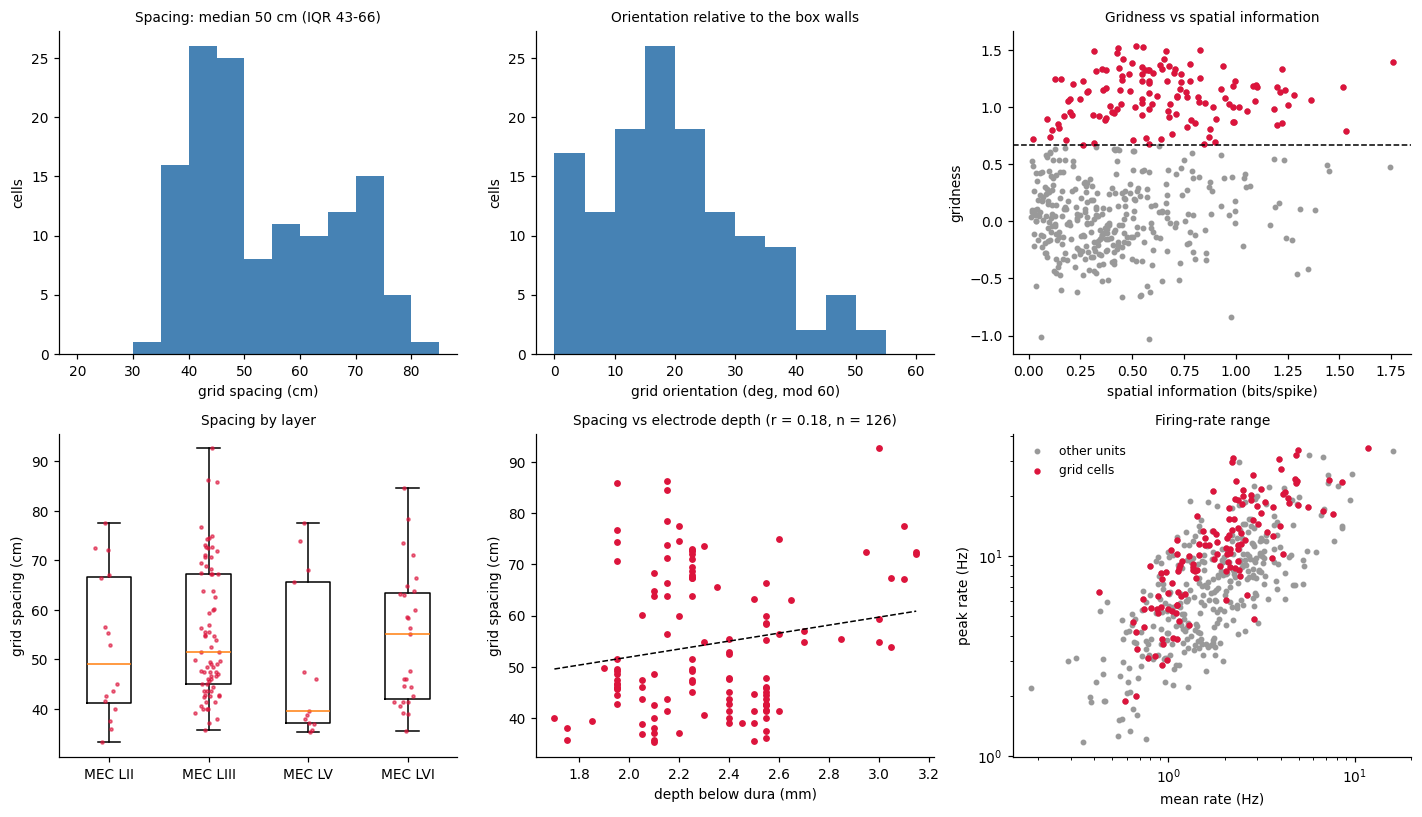

In [16]:
g_ = df[df.is_grid]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
ax = axes[0, 0]
ax.hist(g_["spacing_cm"].dropna(), bins=np.arange(20, 90, 5), color="steelblue")
ax.set_xlabel("grid spacing (cm)"); ax.set_ylabel("cells")
ax.set_title(f"Spacing: median {g_['spacing_cm'].median():.0f} cm (IQR "
             f"{g_['spacing_cm'].quantile(.25):.0f}-{g_['spacing_cm'].quantile(.75):.0f})")
ax = axes[0, 1]
ax.hist(g_["orientation_deg"].dropna(), bins=np.arange(0, 61, 5), color="steelblue")
ax.set_xlabel("grid orientation (deg, mod 60)"); ax.set_ylabel("cells")
ax.set_title("Orientation relative to the box walls")
ax = axes[0, 2]
ax.scatter(df.loc[inc, "spatial_info"], df.loc[inc, "gridness"], s=8, color="0.6")
ax.scatter(g_["spatial_info"], g_["gridness"], s=10, color="crimson")
ax.axhline(THRESH, color="k", ls="--", lw=1)
ax.set_xlabel("spatial information (bits/spike)"); ax.set_ylabel("gridness")
ax.set_title("Gridness vs spatial information")
ax = axes[1, 0]
data = [g_.loc[g_.layer == L, "spacing_cm"].dropna().values for L in layers]
ax.boxplot(data, labels=layers, showfliers=False)
for i, d_ in enumerate(data):
    ax.plot(np.random.default_rng(0).normal(i + 1, 0.06, len(d_)), d_, ".", ms=4,
            color="crimson", alpha=0.6)
ax.set_ylabel("grid spacing (cm)"); ax.set_title("Spacing by layer")
ax = axes[1, 1]
ax.scatter(g_["depth_mm"], g_["spacing_cm"], s=12, color="crimson")
ok = g_[["depth_mm", "spacing_cm"]].dropna()
r_depth = np.corrcoef(ok["depth_mm"], ok["spacing_cm"])[0, 1]
xs = np.linspace(ok["depth_mm"].min(), ok["depth_mm"].max(), 10)
ax.plot(xs, np.polyval(np.polyfit(ok["depth_mm"], ok["spacing_cm"], 1), xs), "k--", lw=1)
ax.set_xlabel("depth below dura (mm)"); ax.set_ylabel("grid spacing (cm)")
ax.set_title(f"Spacing vs electrode depth (r = {r_depth:.2f}, n = {len(ok)})")
ax = axes[1, 2]
ax.scatter(df.loc[inc, "mean_rate"], df.loc[inc, "peak_rate"], s=8, color="0.6",
           label="other units")
ax.scatter(g_["mean_rate"], g_["peak_rate"], s=10, color="crimson", label="grid cells")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mean rate (Hz)"); ax.set_ylabel("peak rate (Hz)")
ax.legend(frameon=False, fontsize=8); ax.set_title("Firing-rate range")
fig.tight_layout(); fig.savefig("fig04_grid_geometry.png", dpi=140)

### 10.5 Conjunctive coding of position and head direction

This is the point of the original paper. Many grid cells in layers III to VI are
also tuned to head direction, so they signal where the animal is and which way it
is facing at the same time. Note that the dandiset was assembled to illustrate
conjunctive and head-direction cells, so the fraction of head-direction-tuned
units here is not an unbiased estimate for MEC as a whole.

{'grid only': 24, 'conjunctive\n(grid x HD)': 58, 'HD only': 176, 'neither': 43}
71% of grid cells with head-direction tracking are also direction tuned


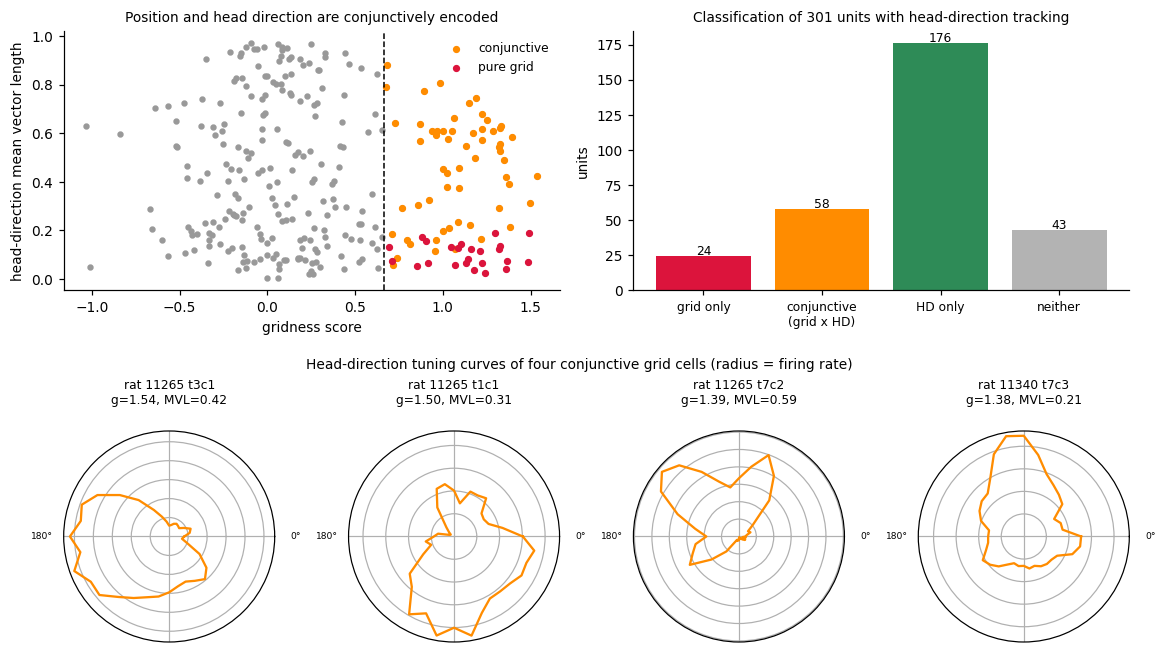

In [17]:
has_hd = inc & np.isfinite(df["hd_mvl"].values)
d_ = df[has_hd]
fig = plt.figure(figsize=(12.5, 7.5))
gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)
ax = fig.add_subplot(gs[0, :2])
ax.scatter(d_["gridness"], d_["hd_mvl"], s=10, color="0.6")
c = d_[d_.is_conj]
ax.scatter(c["gridness"], c["hd_mvl"], s=14, color="darkorange", label="conjunctive")
go = d_[d_.is_grid & ~d_.is_hd]
ax.scatter(go["gridness"], go["hd_mvl"], s=14, color="crimson", label="pure grid")
ax.axvline(THRESH, color="k", ls="--", lw=1)
ax.set_xlabel("gridness score"); ax.set_ylabel("head-direction mean vector length")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Position and head direction are conjunctively encoded")
ax = fig.add_subplot(gs[0, 2:])
cats = {"grid only": int((d_.is_grid & ~d_.is_hd).sum()),
        "conjunctive\n(grid x HD)": int(d_.is_conj.sum()),
        "HD only": int((d_.is_hd & ~d_.is_grid).sum()),
        "neither": int((~d_.is_grid & ~d_.is_hd).sum())}
ax.bar(range(len(cats)), list(cats.values()),
       color=["crimson", "darkorange", "seagreen", "0.7"])
ax.set_xticks(range(len(cats))); ax.set_xticklabels(list(cats), fontsize=8)
ax.set_ylabel("units")
for i, v in enumerate(cats.values()):
    ax.text(i, v + 1, str(v), ha="center", fontsize=8)
ax.set_title(f"Classification of {int(has_hd.sum())} units with head-direction tracking")
fig.text(0.5, 0.47, "Head-direction tuning curves of four conjunctive grid cells "
                    "(radius = firing rate)", ha="center", fontsize=9)
for j, (_, r) in enumerate(d_[d_.is_conj].sort_values(
        "gridness", ascending=False).head(4).iterrows()):
    a = fig.add_subplot(gs[1, j], projection="polar")
    tc = maps[key_of(r, "hdtc")]
    tcs = np.convolve(np.r_[tc[-2:], tc, tc[:2]], np.ones(3) / 3, "same")[2:-2]
    ang = np.linspace(0, 2 * np.pi, len(tc), endpoint=False)
    a.plot(np.append(ang, ang[0]), np.append(tcs, tcs[0]), color="darkorange")
    a.set_title(f"rat {r['subject']} {r['unit']}\ng={r['gridness']:.2f}, "
                f"MVL={r['hd_mvl']:.2f}", fontsize=8, pad=18)
    a.set_yticklabels([])
    a.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""], fontsize=6)
fig.savefig("fig05_conjunctive_cells.png", dpi=140, bbox_inches="tight")
print({k: v for k, v in cats.items()})
print(f"{100 * d_.is_conj.sum() / max(d_.is_grid.sum(), 1):.0f}% of grid cells with "
      f"head-direction tracking are also direction tuned")

### 10.6 Simultaneously recorded grid cells share an orientation

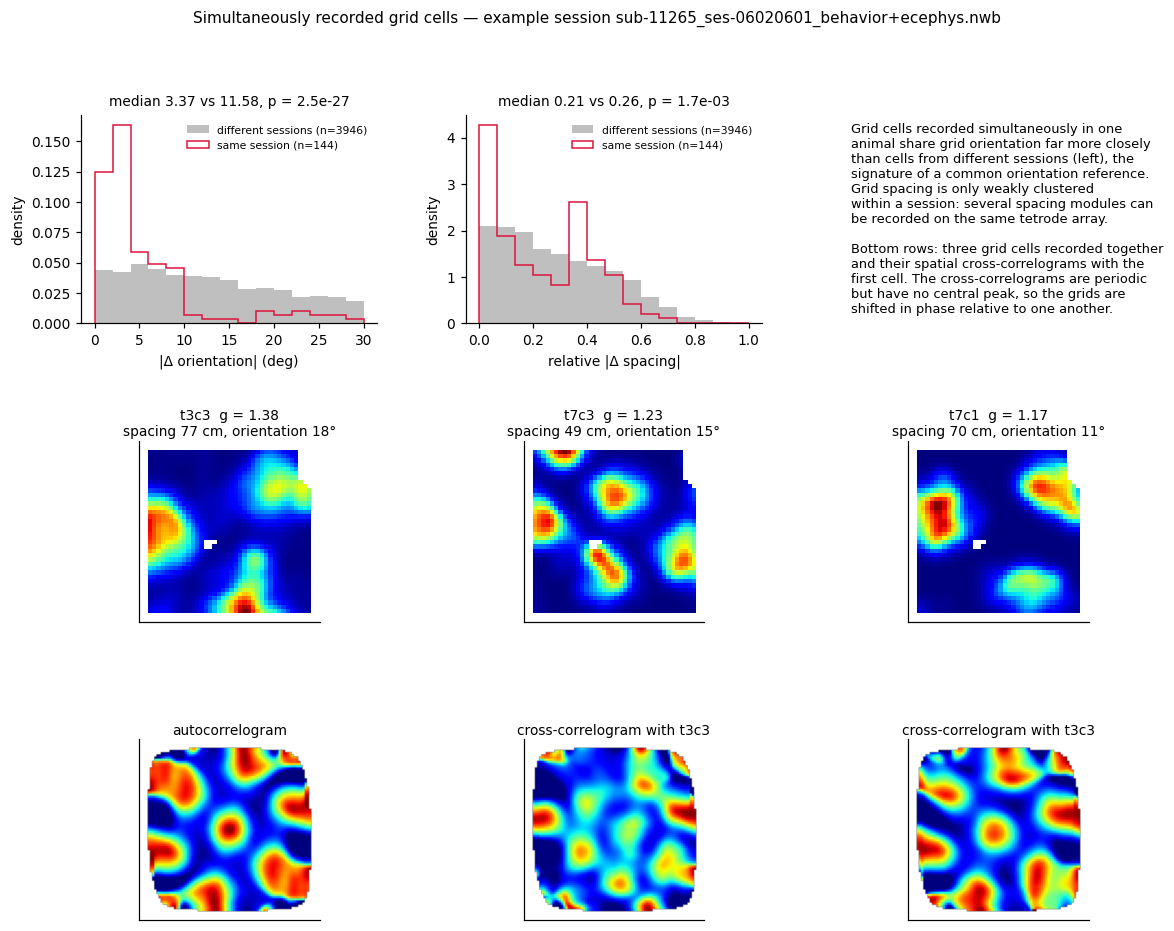

In [18]:
def dorient(a, b):
    d = np.abs(a - b) % 60
    return np.minimum(d, 60 - d)


gg = df[df.is_grid].dropna(subset=["spacing_cm", "orientation_deg"])
rng = np.random.default_rng(3)
within, across = [], []
for path, sub in gg.groupby("path"):
    idx = list(sub.index)
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            r1, r2 = df.loc[idx[i]], df.loc[idx[j]]
            within.append((dorient(r1.orientation_deg, r2.orientation_deg),
                           abs(r1.spacing_cm - r2.spacing_cm) /
                           (0.5 * (r1.spacing_cm + r2.spacing_cm))))
for _ in range(4000):
    i, j = rng.choice(len(gg), 2, replace=False)
    r1, r2 = df.loc[gg.index[i]], df.loc[gg.index[j]]
    if r1["path"] == r2["path"]:
        continue
    across.append((dorient(r1.orientation_deg, r2.orientation_deg),
                   abs(r1.spacing_cm - r2.spacing_cm) /
                   (0.5 * (r1.spacing_cm + r2.spacing_cm))))
within, across = np.array(within), np.array(across)

fig = plt.figure(figsize=(12.5, 9.5))
gsp = fig.add_gridspec(3, 3, height_ratios=[1.15, 1, 1], hspace=0.62, wspace=0.3)
for col, (lab, lim) in enumerate([("|Δ orientation| (deg)", (0, 30)),
                                  ("relative |Δ spacing|", (0, 1.0))]):
    ax = fig.add_subplot(gsp[0, col])
    b = np.linspace(*lim, 16)
    ax.hist(across[:, col], bins=b, density=True, color="0.75",
            label=f"different sessions (n={len(across)})")
    ax.hist(within[:, col], bins=b, density=True, histtype="step", lw=1.8, color="crimson",
            label=f"same session (n={len(within)})")
    _, p = stats.mannwhitneyu(within[:, col], across[:, col])
    ax.set_xlabel(lab); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=7)
    ax.set_title(f"median {np.median(within[:, col]):.2f} vs "
                 f"{np.median(across[:, col]):.2f}, p = {p:.1e}")
ax = fig.add_subplot(gsp[0, 2]); ax.axis("off")
ax.text(0, 0.5, "Grid cells recorded simultaneously in one\nanimal share grid orientation "
                "far more closely\nthan cells from different sessions (left), the\n"
                "signature of a common orientation reference.\nGrid spacing is only weakly "
                "clustered\nwithin a session: several spacing modules can\nbe recorded on "
                "the same tetrode array.\n\nBottom rows: three grid cells recorded together"
                "\nand their spatial cross-correlograms with the\nfirst cell. The "
                "cross-correlograms are periodic\nbut have no central peak, so the grids "
                "are\nshifted in phase relative to one another.", fontsize=8.5, va="center")
path = gg.groupby("path").size().sort_values(ascending=False).index[0]
sub = gg[gg.path == path].sort_values("gridness", ascending=False).head(3)
r0 = sub.iloc[0]
for j, (_, r) in enumerate(sub.iterrows()):
    ax = fig.add_subplot(gsp[1, j])
    show_map(ax, maps[key_of(r, "rm")], f"{r['unit']}  g = {r['gridness']:.2f}\n"
                                        f"spacing {r['spacing_cm']:.0f} cm, "
                                        f"orientation {r['orientation_deg']:.0f}°")
    ax2 = fig.add_subplot(gsp[2, j])
    ax2.imshow(crosscorrelogram(maps[key_of(r0, "rm")], maps[key_of(r, "rm")]),
               origin="lower", cmap="jet", vmin=-0.5, vmax=1)
    ax2.set_xticks([]); ax2.set_yticks([])
    ax2.set_title("autocorrelogram" if j == 0
                  else f"cross-correlogram with {r0['unit']}", pad=3)
fig.suptitle(f"Simultaneously recorded grid cells — example session "
             f"{path.split('/')[-1]}", y=0.98, fontsize=10)
fig.savefig("fig08_grid_modules.png", dpi=140, bbox_inches="tight")

### 10.7 Gallery

The 24 highest-gridness units, unfiltered. Most are unambiguous hexagonal grids;
a couple are band-like rather than hexagonal, which is the expected residual
false-positive rate of any single scalar score.

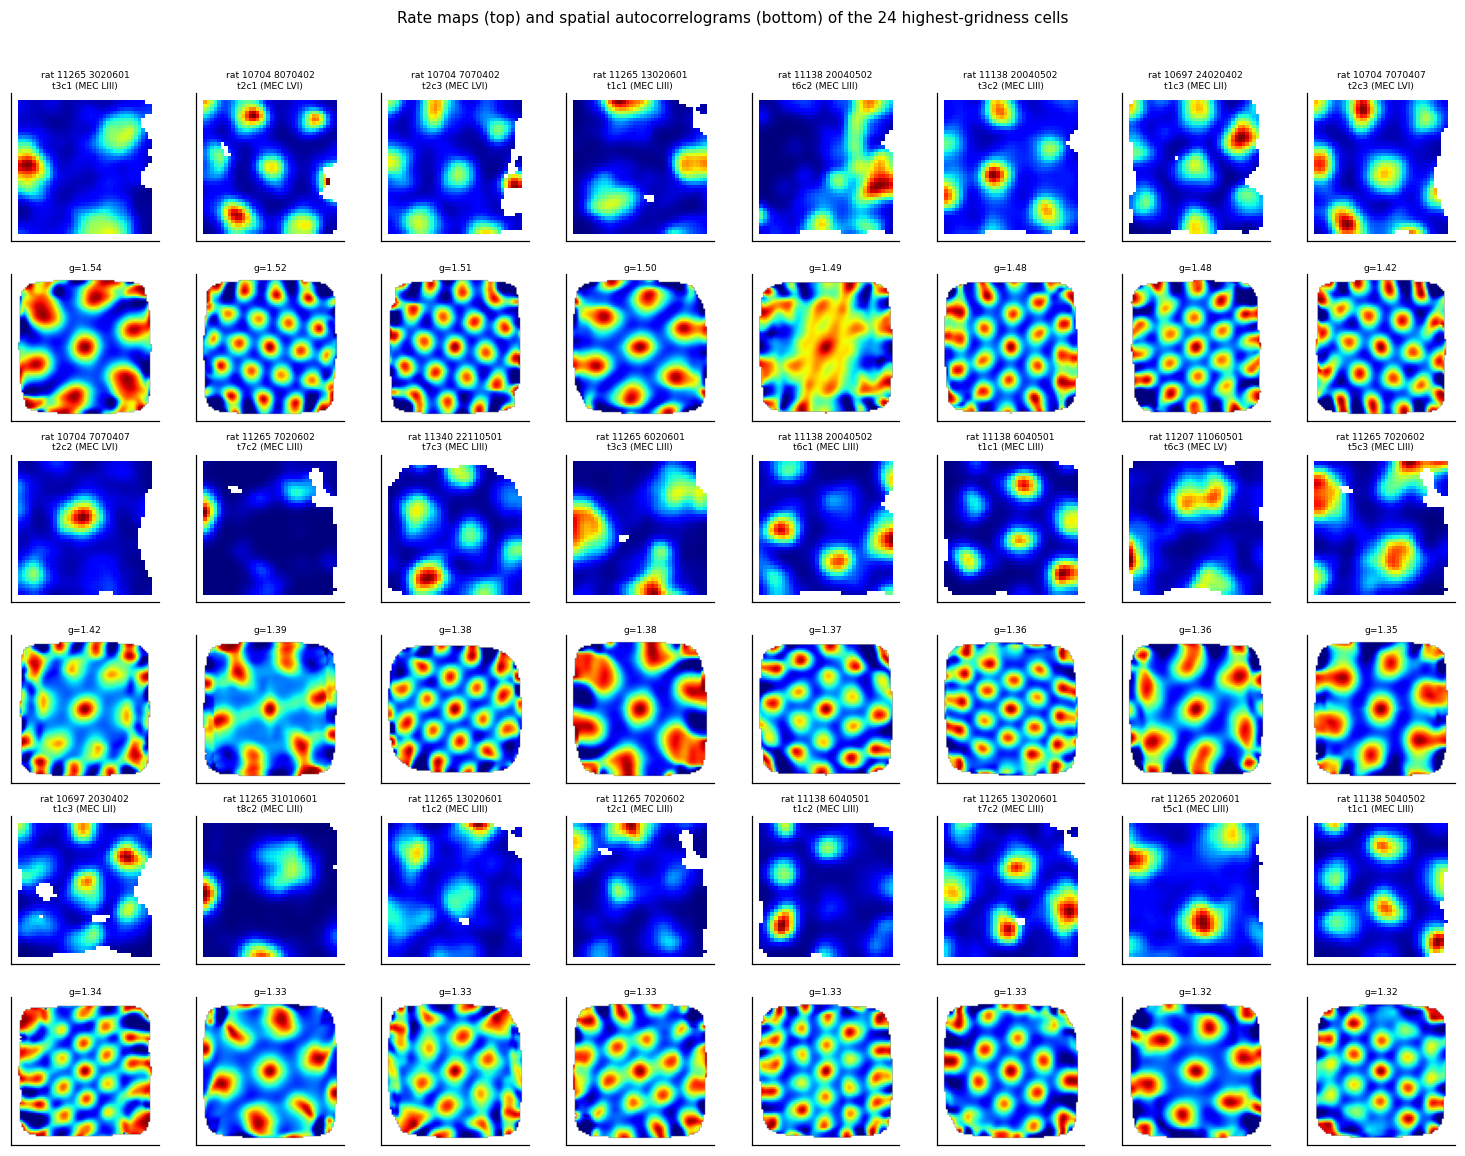

In [19]:
gsel = df[df.is_grid].sort_values("gridness", ascending=False)
n, ncol = min(24, len(gsel)), 8
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow * 2, ncol, figsize=(1.7 * ncol, 3.5 * nrow))
for i in range(nrow * ncol):
    rr, cc = divmod(i, ncol)
    a1, a2 = axes[2 * rr, cc], axes[2 * rr + 1, cc]
    if i >= n:
        a1.axis("off"); a2.axis("off"); continue
    r = gsel.iloc[i]
    show_map(a1, maps[key_of(r, "rm")],
             f"rat {r['subject']} {r['session']}\n{r['unit']} ({r['layer']})")
    a1.title.set_fontsize(6)
    a2.imshow(maps[key_of(r, "ac")], origin="lower", cmap="jet", vmin=-0.6, vmax=1)
    a2.set_xticks([]); a2.set_yticks([])
    a2.set_title(f"g={r['gridness']:.2f}", fontsize=6, pad=2)
fig.suptitle("Rate maps (top) and spatial autocorrelograms (bottom) of the 24 "
             "highest-gridness cells", y=0.995, fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig("fig07_grid_gallery.png", dpi=140)

## 11. Summary

Of 468 well-sampled units recorded in the medial entorhinal cortex of 15 rats
foraging in a 1 m box, 133 (28%) have a gridness score above the 95th percentile
of a spike-train shuffling null, roughly six times the false-positive rate that
threshold implies. Their rate maps show many discrete firing fields on a
triangular lattice and their autocorrelograms have the six-fold symmetry that
defines a grid cell. The pattern is not a sampling accident: it survives a
split-half test of the session, it disappears when the spike train is shifted in
time relative to the same trajectory, and it is far more common in the
superficial layers of MEC than in the deep ones.

The measured geometry matches what is known about dorsocaudal MEC. Grid spacing
is 50 cm at the median (interquartile range 43 to 66 cm), grid orientation is
clustered at small angles to the walls of the box, and peak in-field rates run
from about 2 to 35 Hz. Many of the grid cells are also tuned to head
direction, the conjunctive coding that the source study was written to describe,
and grid cells recorded at the same time in the same animal share a grid
orientation much more closely than cells from different sessions while being
offset from one another in spatial phase.

In [20]:
print(f"units analysed          {int(inc.sum())}")
print(f"sessions / rats         {df.path.nunique()} / {df.subject.nunique()}")
print(f"gridness threshold      {THRESH:.2f}")
print(f"grid cells              {int(df.is_grid.sum())} ({100 * df.is_grid.mean():.1f}%)")
print(f"median spacing          {g_['spacing_cm'].median():.0f} cm")
print(f"median split-half r     grid {g_['stability_r'].median():.2f}, "
      f"other {ng['stability_r'].median():.2f}")
print(f"conjunctive grid cells  {int(df.is_conj.sum())}")

units analysed          468
sessions / rats         96 / 15
gridness threshold      0.66
grid cells              133 (28.4%)
median spacing          50 cm
median split-half r     grid 0.71, other 0.40
conjunctive grid cells  58
